In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [2]:
df = pd.read_csv("../Data/heart_cleaned.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,country,clinical_index
0,28.0,1.0,2.0,130.0,132.0,0.0,2.0,185.0,0.0,0.0,NaN,NaN,NaN,0,Hungary,-3.920000
1,29.0,1.0,2.0,120.0,243.0,0.0,0.0,160.0,0.0,0.0,NaN,NaN,NaN,1,Hungary,-0.670000
2,29.0,1.0,2.0,140.0,241.0,0.0,0.0,170.0,0.0,0.0,NaN,NaN,NaN,0,Hungary,-1.947393
3,30.0,0.0,1.0,170.0,237.0,0.0,1.0,170.0,0.0,0.0,NaN,NaN,6.0,0,Hungary,-1.160000
4,31.0,0.0,2.0,100.0,219.0,0.0,1.0,150.0,0.0,0.0,NaN,NaN,NaN,0,Hungary,-0.690000


Stability Across Regions

This notebook investigates whether the relationships between clinical variables and heart disease are stable across different regions.

The main questions are:

- Does combining regions improve prediction?
- Are key variable effects similar across regions?
- Which variables behave inconsistently?
- Is a single global model appropriate?

In [3]:
df["country"].value_counts()

country
Cleveland      303
Hungary        293
VA             200
Switzerland    122
Name: count, dtype: int64

In [4]:
df.groupby("country")["target"].mean().sort_values()

country
Hungary        0.378840
Cleveland      0.448845
VA             0.740000
Switzerland    0.860656
Name: target, dtype: float64

Disease Prevalence Across Regions

The prevalence of heart disease differs substantially across regions.

Hungary shows the lowest prevalence (37.9%), while Switzerland shows the highest prevalence (86.1%).

These differences suggest that the regions do not represent identical patient populations. Therefore, regional effects may influence predictive performance and should be considered when evaluating a global model.

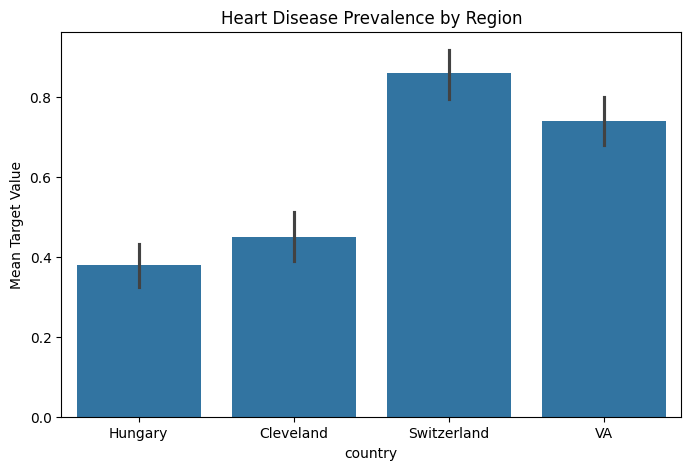

In [5]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="country",
    y="target"
)

plt.title("Heart Disease Prevalence by Region")
plt.ylabel("Mean Target Value")
plt.show()

Are the effects of key variables similar across regions?

In [8]:
df.groupby("country")[["oldpeak", "thalach", "age"]].mean()

,oldpeak,thalach,age
country,,,
Cleveland,1.039604,149.607261,54.438944
Hungary,0.588055,139.134909,47.802048
Switzerland,0.650000,121.422364,55.491803
VA,1.091000,126.700023,59.350000


In [7]:
pd.crosstab(
    df["country"],
    df["exang"],
    normalize="index"
)

exang,0.0,1.0
country,,
Cleveland,0.673267,0.326733
Hungary,0.696246,0.303754
Switzerland,0.557377,0.442623
VA,0.525000,0.475000


In [9]:
pd.crosstab(
    df["country"],
    df["cp"],
    normalize="index"
)

cp,1.0,2.0,3.0,4.0
country,,,,
Cleveland,0.075908,0.165017,0.283828,0.475248
Hungary,0.034130,0.361775,0.184300,0.419795
Switzerland,0.032787,0.032787,0.139344,0.795082
VA,0.040000,0.070000,0.235000,0.655000


In [10]:
pd.crosstab(
    df["country"],
    df["thal"],
    normalize="index"
)

thal,3.0,6.0,7.0
country,,,
Cleveland,0.551495,0.059801,0.388704
Hungary,0.250000,0.357143,0.392857
Switzerland,0.267606,0.140845,0.591549
VA,0.117647,0.235294,0.647059


Are the effects of key variables similar across regions?

Several important predictors show similar patterns across regions.

For example:

- Regions with lower average maximum heart rate (thalach) tend to have higher heart disease prevalence.
- Regions with higher rates of exercise-induced angina (exang) tend to have higher disease prevalence.
- Older populations also tend to show higher disease prevalence.

These findings are consistent with the Logistic Regression coefficients obtained earlier.

However, not all variables behave consistently. In particular, the relationship between oldpeak and disease prevalence appears to vary across regions. Switzerland shows the highest disease prevalence despite having a relatively low average oldpeak value.

In addition, the distributions of chest pain type (cp) and thalassemia status (thal) differ substantially between regions.

Therefore, some predictors show stable patterns across regions, while others exhibit important regional differences.

Which Variables Behave Inconsistently?

Several variables show noticeable differences across regions.

The clearest example is oldpeak. Although higher oldpeak values are generally associated with increased risk, Switzerland exhibits the highest disease prevalence despite having a relatively low average oldpeak value. This suggests that the effect of oldpeak may not be consistent across all regions.

The distributions of chest pain type (cp) and thalassemia status (thal) also vary substantially between regions. In particular, Switzerland and VA show much higher proportions of certain cp and thal categories compared with Hungary and Cleveland.

Therefore, oldpeak, cp, and thal appear to be the variables with the most region-specific behavior, while variables such as thalach and exang show more consistent patterns across regions.

In [11]:
for country in df["country"].unique():
    print(country)
    print(df[df["country"] == country]["target"].value_counts())

Hungary
target
0    182
1    111
Name: count, dtype: int64
Cleveland
target
0    167
1    136
Name: count, dtype: int64
Switzerland
target
1    105
0     17
Name: count, dtype: int64
VA
target
1    148
0     52
Name: count, dtype: int64


In [ ]:
def evaluate_region(region_name):
    
    df_region = df[df["country"] == region_name].copy()

    df_region["slope"] = df_region["slope"].fillna(0)
    df_region["thal"] = df_region["thal"].fillna(0)

    X = df_region.drop(columns=["target"])
    y = df_region["target"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    categorical_features = [
        "sex",
        "cp",
        "fbs",
        "restecg",
        "exang",
        "slope",
        "thal"
    ]

    numerical_features = [
        "age",
        "trestbps",
        "chol",
        "thalach",
        "oldpeak",
        "clinical_index"
    ]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numerical_features),
            ("cat", OneHotEncoder(drop="first"), categorical_features)
        ]
    )

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ])

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:,1]

    roc_auc = roc_auc_score(y_test, y_prob)

    return roc_auc

In [13]:
for region in df["country"].unique():
    print(region, evaluate_region(region))

Hungary 0.6928746928746928
Cleveland 0.8485838779956427
Switzerland 0.3787878787878788
VA 0.5566666666666666


Is a Single Global Model Appropriate?

The regions differ substantially in disease prevalence and in the distributions of several important predictors.

To investigate whether separate regional models would be preferable, Logistic Regression models were trained independently for each region.

The resulting ROC-AUC scores were:

- Cleveland: 0.85
- Hungary: 0.69
- VA: 0.56
- Switzerland: 0.38

Although Cleveland achieved performance similar to the global model, the remaining regions produced substantially lower and less stable results.

This is likely due to the smaller sample sizes available within individual regions.

Therefore, a single global model appears more appropriate because it benefits from the full dataset and produces more stable predictive performance. Regional differences remain important, but these can be incorporated through the country variable rather than building separate models.